## 01. RFM 고객 세분화(Segmentation)

**배우는 이유**
- KMeans 같은 군집화 모델은 단순히 점을 묶는 데서 끝나지 않고, 실제 고객 전략에도 활용됨.
- 고객마다 구매 행동이 다르기 때문에 모든 고객에게 같은 쿠폰이나 메시지를 보내면 효율이 떨어짐.
- RFM은 거래 데이터를 고객 행동 feature로 바꾸는 대표적인 방법이라 초보자가 실무 활용 흐름을 이해하기 좋음.

**어디서 사용하는가?**
- 쇼핑몰 고객 등급 분류
- VIP 고객 관리
- 이탈 위험 고객 찾기
- 재구매 쿠폰/추천 캠페인 대상 선정
- CRM, 마케팅 자동화, 추천 시스템의 기초 feature 생성

**핵심 용어**
- `Recency`: 마지막 구매가 얼마나 최근인지 나타내는 값. 여기서는 마지막 구매 후 지난 일수이므로 낮을수록 최근 구매 고객임.
- `Frequency`: 일정 기간 동안 구매한 주문 횟수. 높을수록 반복 구매 고객임.
- `Monetary`: 일정 기간 동안 구매한 총 금액. 높을수록 구매 규모가 큰 고객임.
- `고객 세분화`: 비슷한 행동을 보이는 고객을 그룹으로 나누고 각 그룹에 다른 전략을 적용하는 작업임.

**주의할 점**
- 군집 label `0`, `1`, `2` 자체에는 비즈니스 의미가 없음.
- 모델은 비슷한 고객을 묶어줄 뿐이고, VIP/신규/이탈 위험 같은 이름은 사람이 RFM 평균을 보고 붙여야 함.


## 02. 실습 환경 준비

UCI 온라인 리테일 엑셀 데이터를 URL에서 직접 읽어 사용할 예정 이기 때문에 `openpyxl` 라이브러리 필요

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


## 03. 온라인 리테일 데이터 로드

https://archive.ics.uci.edu/dataset/352/online+retail

UCI Online Retail 형태의 거래 데이터임.
행 하나는 고객 한 명이 아니라 **상품 구매 내역 한 줄**을 의미함.
따라서 RFM 분석을 하려면 거래 데이터를 고객 단위로 다시 집계해야 함.

주요 컬럼은 다음과 같음.

- `InvoiceNo`: 주문 번호. `C`로 시작하면 취소 주문으로 볼 수 있음.
- `StockCode`: 상품 코드.
- `Description`: 상품명.
- `Quantity`: 구매 수량. 취소/오류 데이터에는 음수가 있을 수 있음.
- `InvoiceDate`: 주문 일시.
- `UnitPrice`: 상품 단가. 0 이하 값은 정상 구매 분석에서 제외함.
- `CustomerID`: 고객 ID. RFM은 고객 단위 분석이므로 결측치가 있으면 제외함.
- `Country`: 국가.


In [2]:
# 온라인에서 직접 excel 파일을 다운 받아오기
retail_df = pd.read_excel('https://d.pr/f/BlExJX+')

# 다운로드 불가 시 excel 파일 직접 읽어오기
# retail_df = pd.read_excel('data/OnlineRetail.xlsx')

retail_df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 04. 원본 데이터 기본 확인

실제 데이터는 바로 분석에 쓰기 어렵기 때문에 먼저 결측치, 취소 주문, 음수 수량/가격을 확인함.

특히 RFM에서는 `CustomerID`, `InvoiceDate`, `InvoiceNo`, `Quantity`, `UnitPrice`가 중요함.


In [12]:
print("원본 데이터 shape: ", retail_df.shape)

retail_df.info() # 컬럼별 자료형, 데이터의 수, 결측치 등을 확인

# 컬럼별 결측치 수
missing_df = retail_df.isna().sum().to_frame('missing_count')
display(missing_df)

# 수치형 컬럼의 평균, 표준편차, 최솟값/최댓값 요약 설명
# -> 'Quantity', 'UnitPrice' 데이터 중 0 또는 음수가 발견됨
# == 이상치 존재
display(retail_df[['Quantity', 'UnitPrice']].describe(), round(2))

# 취소된 주문의 수 (InvoiceNo가 C로 시작하면 취소된 주문
cancel_count = retail_df['InvoiceNo'].astype(str).str.startswith('C')
print('취소 주문 행 수')

# 국가별 거래 행 수 확인
display(retail_df['Country'].value_counts().head(10).to_frame('row_count'))

원본 데이터 shape:  (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


,missing_count
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


2

취소 주문 행 수


,row_count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


## 05. RFM 분석용 거래 데이터 전처리

RFM은 정상 구매 행동을 요약하는 분석이므로 아래 행은 제외함.

- `CustomerID`가 없는 행: 어떤 고객의 거래인지 알 수 없음.
- `InvoiceNo`가 `C`로 시작하는 행: 취소 주문으로 볼 수 있음.
- `Quantity <= 0`: 정상 구매 수량이 아님.
- `UnitPrice <= 0`: 정상 구매 금액 계산에 부적절함.

전처리 후 `SaleAmount = Quantity × UnitPrice`를 만들어 고객별 구매 금액 집계에 사용함.


In [14]:
before_rows = len(retail_df)

# CustomerID가 없는 행 제거
retail_clean_df = retail_df.dropna(subset = ['CustomerID']).copy()
after_customer_filter = len(retail_clean_df)

# 주문 취소 행 제거(InvoiceNo가 C로 시작 == 취소)
retail_clean_df = retail_clean_df[~retail_clean_df['InvoiceNo'].astype(str).str.startswith('C')]
after_cancel_filter = len(retail_clean_df)

# Quantity, UnitPrice가 0 이하인 행 제거
retail_clean_df = retail_clean_df[
    (retail_clean_df['Quantity'] > 0 )
    & (retail_clean_df['UnitPrice'] > 0 )].copy()
after_positive_filter = len(retail_clean_df)

# SaleAmount 컬럼 추가
retail_clean_df['SaleAmount'] \
    = retail_clean_df['Quantity'] * retail_clean_df['UnitPrice']

# CustomerID의 자료형을 float -> str(정수 문자열)로 변경
retail_clean_df['CustomerID'] = retail_clean_df['CustomerID'].astype(int).astype(str)

cleaning_summary_df = pd.DataFrame({
    'step': [
        'original',
        'drop missing CustomerID',
        'remove canceled invoices',
        'keep positive Quantity/UnitPrice'
    ],
    'row_count': [
        before_rows,
        after_customer_filter,
        after_cancel_filter,
        after_positive_filter
    ]
})
cleaning_summary_df['removed_rows'] = cleaning_summary_df['row_count'].shift(1) - cleaning_summary_df['row_count']

# 첫 단계의 removed_rows는 비교 대상이 없으므로 0으로 표시함.
cleaning_summary_df['removed_rows'] = cleaning_summary_df['removed_rows'].fillna(0).astype(int)

display(cleaning_summary_df)
display(retail_clean_df.head())
print('정리 후 고객 수:', retail_clean_df['CustomerID'].nunique())

,step,row_count,removed_rows
0,original,541909,0
1,drop missing CustomerID,406829,135080
2,remove canceled invoices,397924,8905
3,keep positive Quantity/UnitPrice,397884,40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SaleAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


정리 후 고객 수: 4338


## 06. 고객 단위 RFM feature 생성

거래 데이터는 한 고객이 여러 행을 가질 수 있다.

RFM 분석에서는 고객 1명이 행 1개가 되도록 집계해야 한다.

- `Recency`: 분석 기준일 - 고객의 마지막 구매일
- `Frequency`: 고객의 고유 주문 수
- `Monetary`: 고객의 총 구매 금액

여기서는 분석 기준일을 데이터의 마지막 주문일 다음 날로 둠.


In [16]:
# 거래 단위 데이터 -> 고객 단위 데이터로 변환(RFM feature 이용)

# 분석 기준일 설정
# - 데이터의 마지막 주문일 다음날(+1)로 설정
analysis_date = retail_clean_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# groupby('CustomerID'): 고객별로 거래 행을 묶음.
# LastPurchaseDate: 고객의 마지막 구매일.
# Frequency: 고객이 몇 번 주문했는지 보기 위해 InvoiceNo의 고유 개수를 계산함.
# Monetary: 고객이 쓴 총 금액을 보기 위해 SaleAmount를 합산함.
rfm_df = retail_clean_df.groupby("CustomerID").agg(
    LastPurchaseDate = ("InvoiceDate", "max"), # 해당 고객의 최근 구매일
    Frequency = ("InvoiceNo", "nunique"), # 해당 고객의 주문 횟수
    Monetary = ("SaleAmount", "sum") # 해당 고객이 쓴 총 금액
)

# Recency: 분석 기준일에서 마지막 구매일까지 지난 일수.
# 값이 낮을수록 최근에 구매한 고객임.
rfm_df['Recency'] = (analysis_date - rfm_df['LastPurchaseDate']).dt.days

# 군집화에는 날짜 자체가 아니라 RFM 숫자 feature만 사용함.
rfm_df = rfm_df[['Recency', 'Frequency', 'Monetary']]

print('분석 기준일:', analysis_date)
print('RFM 고객 수:', len(rfm_df))
display(rfm_df.head())
display(rfm_df.describe().round(2))

분석 기준일: 2011-12-10 12:50:00
RFM 고객 수: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27
std,100.01,7.70,8989.23
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.00,5.00,1661.74
max,374.00,209.00,280206.02


## 07. RFM 분포 확인과 로그 변환

RFM 값은 보통 한쪽으로 크게 치우쳐 있다..
예를 들어 대부분 고객은 구매 횟수와 금액이 작고, 일부 VIP 고객만 매우 큰 값을 가질 수 있다.

KMeans는 거리 기반 모델이므로 극단적으로 큰 값이 있으면 중심점 계산에 큰 영향을 줄 수 있다.

그래서 `np.log1p()`로 큰 값을 완만하게 줄인 뒤 군집화를 진행한다.


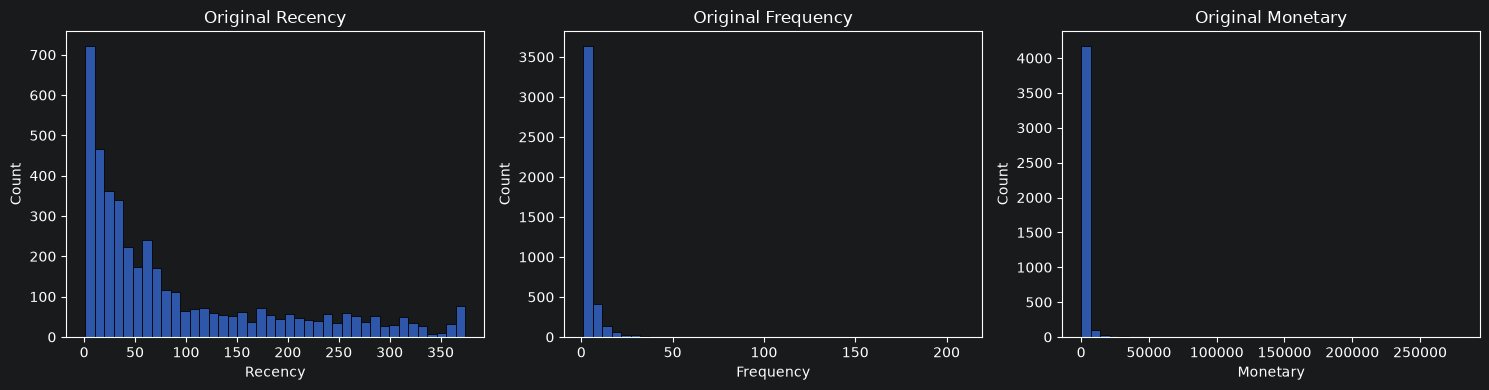

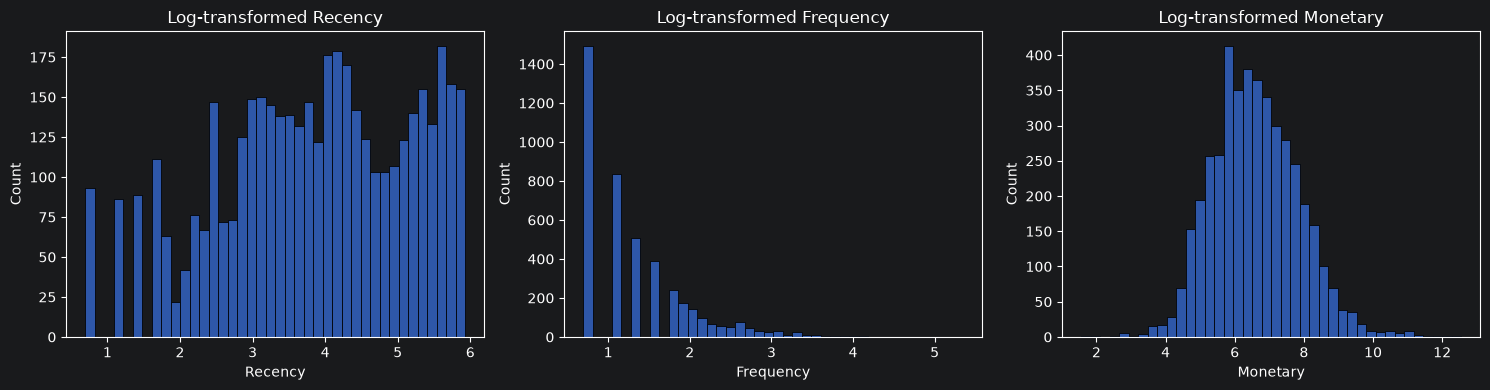

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    # histplot(): 값의 분포를 히스토그램으로 보여줌.
    # bins는 막대 구간 개수이며, 값이 클수록 더 잘게 나누어 봄.
    sns.histplot(rfm_df[col], bins=40, ax=ax)
    ax.set_title(f'Original {col}')

plt.tight_layout()
plt.show()

# np.log1p(x): log(1 + x)를 계산함.
# 0에 가까운 값도 안전하게 처리할 수 있어 구매 횟수/금액 데이터에 자주 사용함.
rfm_log_df = np.log1p(rfm_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_log_df[col], bins=40, ax=ax)
    ax.set_title(f'Log-transformed {col}')

plt.tight_layout()
plt.show()

## 08. RFM 스케일링

`Recency`, `Frequency`, `Monetary`는 단위와 숫자 범위가 서로 다르다.

KMeans는 거리 기반 모델이라 스케일이 큰 feature가 군집화 결과를 지배할 수 있기 때문에.

로그 변환한 RFM 값을 `StandardScaler`로 평균 0, 표준편차 1 수준으로 맞춰준다


In [20]:
rfm_scaler = StandardScaler()

# log scale로 변환된 데이터를 한번더 스케일링
rfm_scaled = rfm_scaler.fit_transform(rfm_log_df)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns = rfm_log_df.columns,
    index = rfm_log_df.index
)

display(rfm_scaled_df.describe().loc[['mean', 'std']].round(2))

,Recency,Frequency,Monetary
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0


## 09. 적절한 k 후보 비교

KMeans는 군집 수 `k`를 사람이 정해야 한다.
여기서는 두 지표를 함께 확인한다.

- `inertia`: 각 고객이 자기 군집 중심에서 얼마나 떨어져 있는지 합산한 값. 낮을수록 군집 안이 조밀함.
- `silhouette_score`: 군집 안에서는 가깝고 다른 군집과는 멀리 떨어졌는지 보는 지표. 높을수록 좋음.

다만 고객 세분화에서는 지표가 가장 좋은 k만 고르지 않고,
마케팅 액션으로 설명 가능한 군집 수인지도 함께 봐야 함.


,k,inertia,silhouette_score
0,2,6481.225,0.433
1,3,4867.847,0.337
2,4,3938.510,0.337
3,5,3295.976,0.316
4,6,2855.011,0.313
5,7,2548.914,0.310
6,8,2336.778,0.301


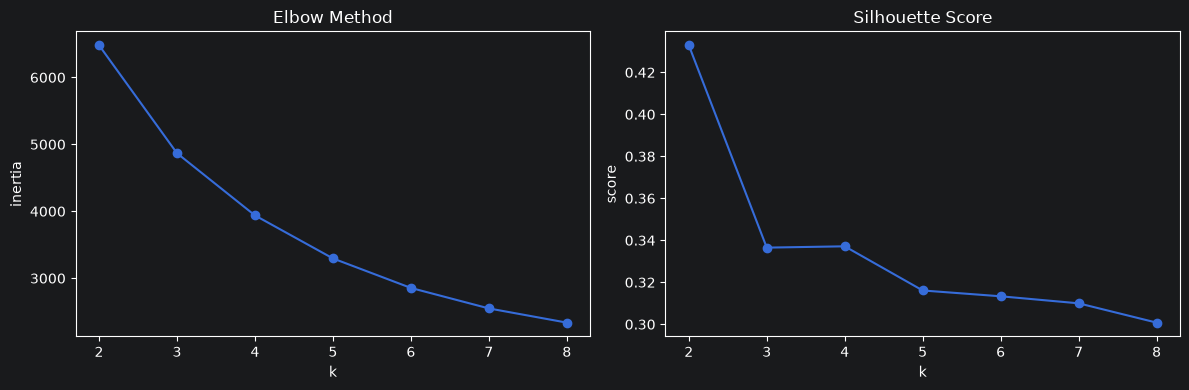

In [22]:
# k 후보 생성
k_values = range(2,9)
k_results = []

for k in k_values:
    # KMeans 모델 생성(군집 수 k를 바꿔 가면서 학습)
    model = KMeans(n_clusters=k, n_init=10,random_state=42)

    # 모델을 학습시키고 예측한 군집(cluster) label을 반환
    labels = model.fit_predict(rfm_scaled_df)


    # inertia : 데이터와 중심점 사이 거리의 합(낮을 수록 좋다)
    # silhouette_score() : 군집의 조밀함 + 군집간의 거리 점수 (-1 ~ 1, 높을수록 좋다)
    k_results.append({
        'k': k,
        'inertia' : model.inertia_,
        'silhouette_score': silhouette_score(rfm_scaled_df, labels),
    })
k_result_df = pd.DataFrame(k_results)
display(k_results_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_result_df['k'], k_result_df['inertia'], marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')

axes[1].plot(k_result_df['k'], k_result_df['silhouette_score'], marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('score')

plt.tight_layout()
plt.show()

# Elbow Method k 후보 : 3,4
# Silhouette_Score k 후보 3,4
# -> 여러 고객(군집) 별 페르소나를 적용해보기 위해 k=4로 설정


## 10. KMeans로 고객 군집 생성

앞에서 지표를 확인했을 때 `k=2`가 실루엣 점수는 높을 수 있지만.
고객 세분화 시 VIP, 최근 구매 고객, 이탈 위험 고객, 저활성 고객처럼 여러 마케팅 전략을 비교하고 설명하는 것이 어려울 수 있다.

따라서 여기서는 설명 가능한 페르소나를 만들기 위해 `k=4`를 사용한다.
실무에서는 지표, 캠페인 운영 가능성, 도메인 지식을 함께 보고 k를 결정한다.


In [23]:
selected_k = 4

rfm_kmeans = KMeans(
    n_clusters=selected_k,
    n_init=10,
    random_state=42
)

# 학습 및 군집 예측
rfm_labels = rfm_kmeans.fit_predict(rfm_scaled_df)

rfm_result_df = rfm_df.copy()

# 결과 확인용 DataFrame
rfm_result_df = rfm_df.copy()
rfm_result_df['cluster'] = rfm_labels

#군집 번호 별 고객 수 확인
cluster_count_df = rfm_result_df["cluster"].value_counts().sort_index().to_frame('customer_count')

display(rfm_result_df.head())
display(cluster_count_df)

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,1
12348,75,4,1797.24,2
12349,19,1,1757.55,0
12350,310,1,334.40,3


,customer_count
cluster,
0,837
1,716
2,1173
3,1612


## 11. 군집별 RFM 특징 해석

군집화 모델은 `cluster` 번호만 만들어 준다.

이 번호를 고객 유형으로 바꾸려면 군집별 RFM 평균을 비교해야 한다.

- `Recency` 평균이 낮다: 최근에 구매한 고객이 많음.
- `Frequency` 평균이 높다: 반복 구매가 많음.
- `Monetary` 평균이 높다: 구매 금액 규모가 큼.


,cluster,customer_count,recency_mean,frequency_mean,monetary_mean
0,0,837,18.12,2.15,551.82
1,1,716,12.13,13.71,8074.27
2,2,1173,71.08,4.08,1802.83
3,3,1612,182.50,1.32,343.45


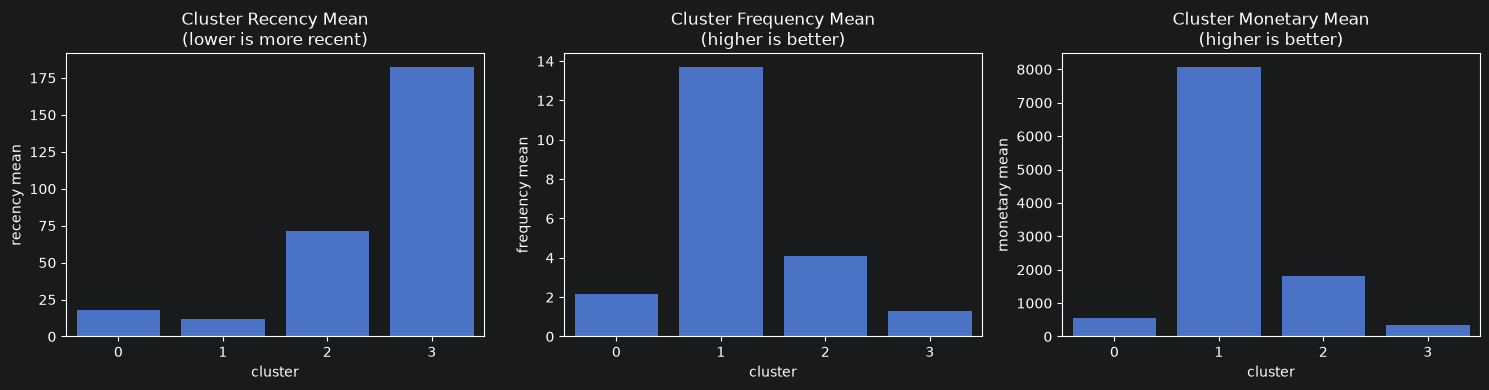

In [24]:
cluster_summary = rfm_result_df.groupby('cluster').agg(
    customer_count=('Recency', 'count'),
    recency_mean=('Recency', 'mean'),
    frequency_mean=('Frequency', 'mean'),
    monetary_mean=('Monetary', 'mean'),
).round(2).reset_index()

display(cluster_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=cluster_summary, x='cluster', y='recency_mean', ax=axes[0])
axes[0].set_title('Cluster Recency Mean\n(lower is more recent)')
axes[0].set_xlabel('cluster')
axes[0].set_ylabel('recency mean')

sns.barplot(data=cluster_summary, x='cluster', y='frequency_mean', ax=axes[1])
axes[1].set_title('Cluster Frequency Mean\n(higher is better)')
axes[1].set_xlabel('cluster')
axes[1].set_ylabel('frequency mean')

sns.barplot(data=cluster_summary, x='cluster', y='monetary_mean', ax=axes[2])
axes[2].set_title('Cluster Monetary Mean\n(higher is better)')
axes[2].set_xlabel('cluster')
axes[2].set_ylabel('monetary mean')

plt.tight_layout()
plt.show()

## 12. PCA 2차원 시각화로 군집 확인

군집 결과를 직관적으로 보기 위한 참고용 시각화.

RFM feature는 3개라 화면에 바로 그리기 어렵기 때문에 PCA로 2차원 좌표를 만든다.

주의할 점은 PCA 그래프가 원본 3차원 RFM 정보를 완벽하게 보존하는 것은 아니라는 점이다.
따라서 최종 해석은 그래프만 보지 말고 군집별 RFM 평균 표와 함께 봐야 한다.

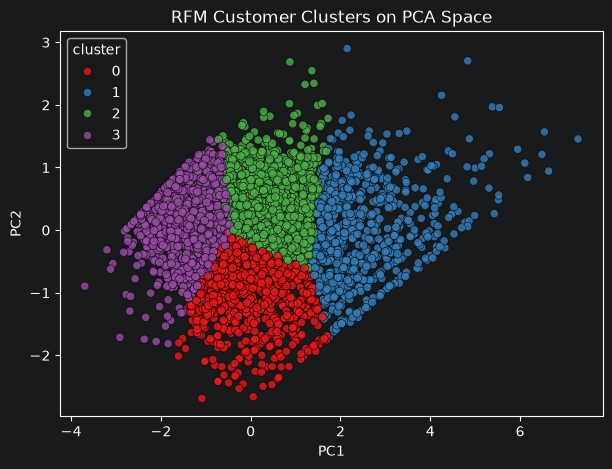

PCA 설명 분산 비율: [0.751  0.1876]
누적 설명 분산 비율: 0.9386


In [25]:
rfm_pca = PCA(n_components=2)
rfm_pca_2d = rfm_pca.fit_transform(rfm_scaled_df)

# 시각화용 DF 생성
rfm_plot_df = pd.DataFrame(
    rfm_pca_2d,
    columns = ['PC1', 'PC2'],
    index = rfm_scaled_df.index
)

rfm_plot_df['cluster'] = rfm_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=rfm_plot_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    alpha=0.8,
    edgecolor='black'
)
plt.title('RFM Customer Clusters on PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()

print('PCA 설명 분산 비율:', np.round(rfm_pca.explained_variance_ratio_, 4))
print('누적 설명 분산 비율:', round(rfm_pca.explained_variance_ratio_.sum(), 4))

## 13. 군집 페르소나와 대응 전략 만들기

군집화의 마지막 단계는 label을 붙이는 것이 아니라 **해석 가능한 고객 유형**을 만드는 것이다.

군집별 평균을 전체 평균과 비교해 간단한 페르소나를 붙여볼 예정.

실무에서는 이 규칙을 그대로 쓰기보다, 서비스 도메인과 캠페인 목적에 맞게 기준을 조정해야한다.


In [32]:
# RFM의 전체 평균
overall_recency = rfm_result_df['Recency'].mean()
overall_frequency = rfm_result_df['Frequency'].mean()
overall_monetary = rfm_result_df['Monetary'].mean()

# -> 평균들을 이용해서 군집을 상대적으로 해석하기 위한 기준선으로 사용

# 페르소나 설정
# - VIP/충성고객 : 최근 구매했고, 구매빈도 높고, 누적 사용 금액 높음
# - 반복 구매하는 일반 고객: 최근 구매했고, 구매 빈도 높고, 금액 낮음
# - 신규 고객 : 최근에 구매했고, 구매 빈도 낮음. 금액 낮음
# - 이탈 우려 우수 고객: 최근 구매 X, 구매 빈도 높고, 누적 사용 금액 높음
# - 저활성 이탈 위험 고객: 최근 구매 X, 구매빈도 낮음, 누적 사용 금액 낮음

persona_rows = []
for _, row in cluster_summary.iterrows():
    # row == 군집별 R, F, M의 평균이 들어있는 시리즈
    cluster = row['cluster']
    recency= row['recency_mean']
    frequency= row['frequency_mean']
    monetary= row['monetary_mean']

    # - VIP/충성고객 : 최근 구매했고, 구매빈도 높고, 누적 사용 금액 높음
    if recency < overall_recency and frequency > overall_frequency and monetary > overall_monetary:
        persona = "VIP 또는 충성 고객"
        strategy = "프리미엄 혜택, 멤버쉽 유지, 개인 전용 서비스 제공"

    # - 반복 구매하는 일반 고객: 최근 구매했고, 구매 빈도 높고, 금액 낮음
    elif recency < overall_recency and frequency > overall_frequency :
        persona = "반복 구매하는 일반 고객"
        strategy = "재구매 혜택, 묶음 상품 추천, 마일리지 추가 적립"

    # - 신규 고객 : 최근에 구매했고, 구매 빈도 낮음. 금액 낮음
    elif recency < overall_recency and frequency < overall_frequency and monetary < overall_monetary:
        persona = "신규 고객 또는 성장 가능 고객"
        strategy = "첫구매 쿠폰, 관심 상품 추천"

    # - 이탈 우려 우수 고객: 최근 구매 X, 구매 빈도 높고, 누적 사용 금액 높음
    elif recency >= overall_recency and (frequency > overall_frequency or monetary > overall_monetary):
        persona = "이탈 우려 우수 고객"
        strategy = "복귀 혜택, 한정 프로모션, 휴면 계정 전환 알림"

    # - 저활성 이탈 위험 고객: 최근 구매 X, 구매빈도 낮음, 누적 사용 금액 낮음
    else :
        persona = "저활성 이탈 위험 고객"
        strategy = "저비용 상품 프로모션, 복귀 혜택"

    persona_rows.append({
        'cluster': cluster,
        'persona': persona,
        'recommended_action' : strategy
    })

persona_df = pd.DataFrame(persona_rows)
cluster_persona_df = cluster_summary.merge(persona_df, on='cluster')
display(cluster_persona_df)

,cluster,customer_count,recency_mean,frequency_mean,monetary_mean,persona,recommended_action
0,0,837,18.12,2.15,551.82,신규 고객,"첫구매 쿠폰, 관심 상품 추천"
1,1,716,12.13,13.71,8074.27,VIP 또는 충성 고객,"프리미엄 혜택, 멤버쉽 유지, 개인 전용 서비스 제공"
2,2,1173,71.08,4.08,1802.83,신규 고객,"첫구매 쿠폰, 관심 상품 추천"
3,3,1612,182.50,1.32,343.45,저활성 이탈 위험 고객,"저비용 상품 프로모션, 복귀 혜택"


## 14. 수업 마무리 정리

- RFM은 거래 데이터를 고객 행동 feature로 바꾸는 대표적인 방법임.
- 실제 데이터에서는 결측치, 취소 주문, 음수 수량/가격 같은 전처리 기준을 먼저 정해야 함.
- KMeans를 적용하기 전 RFM 분포의 치우침과 스케일 차이를 처리해야 함.
- `k`는 지표만으로 결정하지 않고, 세분화 결과를 실제 액션으로 설명할 수 있는지도 함께 봐야 함.
- 군집화 결과는 정답 label이 아니라 해석이 필요한 그룹 번호임.
- 프로젝트에서는 군집별 특성을 문장으로 설명하고, 어떤 비즈니스 액션을 할지까지 연결해야 의미가 있음.
